# Model 1: From Scratch DCNN
Designed by: Theo Negrao

A small VGG-style CNN trained from scratch. [ADD MORE!]

In [ ]:
import sys
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sys.path.append("..")
from shared_utils import (
    PROJECT_ROOT,
    load_data,
    eval_model,
    save_metrics,
    plot_training_history,
    get_class_weights,
)

In [2]:
# Configurations

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Directory to save figures
FIGURES_DIR = PROJECT_ROOT / "scratch_cnn" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Data Loading
data = load_data()

train_paths = data["train_paths"]
val_paths = data["val_paths"]
test_paths = data["test_paths"]

train_labels = data["train_labels"]
val_labels = data["val_labels"]
test_labels = data["test_labels"]

class_list = data["class_list"]
NUM_CLASSES = len(class_list)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))
print("Classes:", class_list)

print()
print("Example train image:")
print(train_paths[0])
print("Exists:", Path(train_paths[0]).exists())

Train: 10859
Val: 2328
Test: 2328
Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']

Example train image:
/home/n11902736/cab420/WasteClassification/data/garbage_classification/clothes/clothes3810.jpg
Exists: True


## Data Preprocessing
2 datasets created:
 - train_ds = shuffled, augmented during training
 - train_eval_ds = not shuffled, used only for train-set predictions/evaluation

Preprocessing:
 - resize to 128x128
 - normalize to [0,1]
 - augmentations:
    - Horizontal Flip
    - Rotation
    - Zoom
    - Translation

In [4]:
# Image loading settings
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

I0000 00:00:1779806948.592688   13305 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1880 MB memory:  -> device: 0, name: NVIDIA A16-4Q, pci bus id: 0000:04:08.0, compute capability: 8.6


Datasets created.


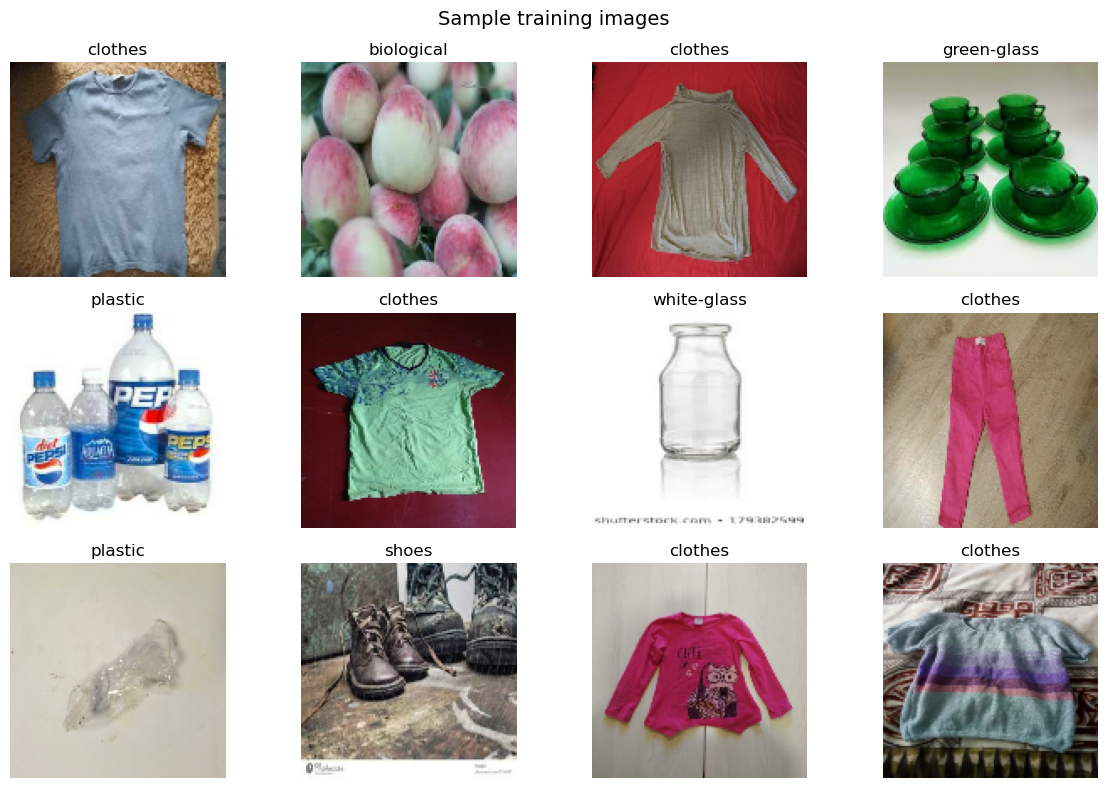

Saved: /home/n11902736/cab420/WasteClassification/scratch_cnn/figures/sample_training_images.png


In [5]:
def load_image(path, label):
    """
    Load one image file and return image tensor plus label.

    Images are:
    - decoded as RGB
    - resized to IMG_SIZE
    - normalised to [0, 1]
    """
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=2000, seed=RANDOM_STATE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Non-shuffled version for train-set evaluation later.
train_eval_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_eval_ds = train_eval_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_eval_ds = train_eval_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Datasets created.")

# Visualize training batch
images, labels = next(iter(train_ds))

fig = plt.figure(figsize=(12, 8))

for i in range(12):
    ax = fig.add_subplot(3, 4, i + 1)
    ax.imshow(images[i])
    ax.set_title(class_list[int(labels[i])])
    ax.axis("off")

fig.suptitle("Sample training images", fontsize=14)
plt.tight_layout()

figure_path = FIGURES_DIR / "sample_training_images.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

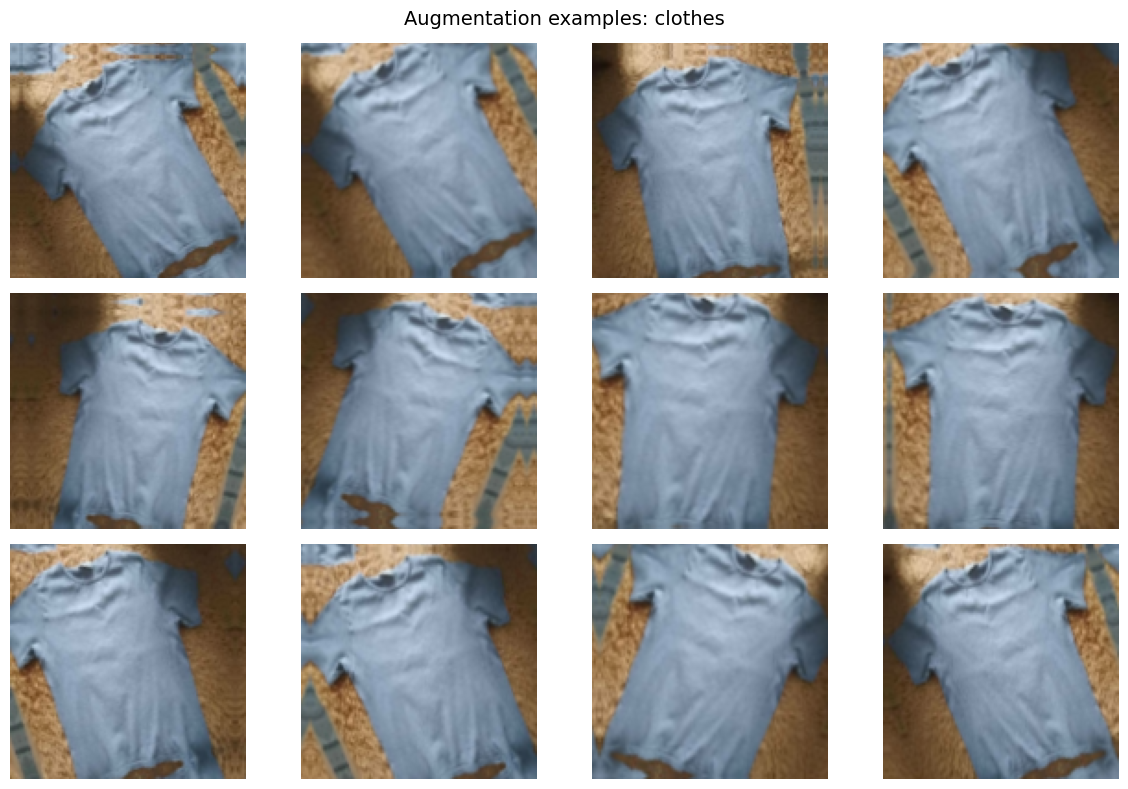

Saved: /home/n11902736/cab420/WasteClassification/scratch_cnn/figures/augmentation_examples.png


In [6]:
# Data Augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomTranslation(0.05, 0.05),
    ],
    name="data_augmentation",
)

# Visualize examples
sample_image = images[0]

fig = plt.figure(figsize=(12, 8))

for i in range(12):
    ax = fig.add_subplot(3, 4, i + 1)
    augmented = data_augmentation(tf.expand_dims(sample_image, axis=0), training=True)
    ax.imshow(augmented[0])
    ax.axis("off")

fig.suptitle(f"Augmentation examples: {class_list[int(labels[0])]}", fontsize=14)
plt.tight_layout()

figure_path = FIGURES_DIR / "augmentation_examples.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

## Class Weights
Attempt to compensate class imbalance: large 'clothes' class in relation to others.
- This does not change the validation/test distribution, it only affects the loss during training.

In [7]:
class_weights = get_class_weights(train_labels)

print("Class weights:")
for label, weight in class_weights.items():
    print(f"{label:>2d} {class_list[label]:>15s}: {weight:.3f}")

Class weights:
 0         battery: 1.369
 1      biological: 1.313
 2     brown-glass: 2.129
 3       cardboard: 1.453
 4         clothes: 0.243
 5     green-glass: 2.052
 6           metal: 1.679
 7           paper: 1.231
 8         plastic: 1.496
 9           shoes: 0.654
10           trash: 1.854
11     white-glass: 1.667


## Build From Scratch DCNN
Small VGG-style CNN.

In [8]:
def build_scratch_cnn(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.40)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="scratch_cnn")

    return model


model = build_scratch_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES,
)

model.summary()

Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,291,084 (4.93 MB)

 Trainable params: 1,291,084 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile Model
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Set Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
    )
]

# Train Model
EPOCHS = 30

start_time = time.perf_counter()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,
)
train_time = time.perf_counter() - start_time

print(f"Training time: {train_time:.2f}s")

Epoch 1/30


I0000 00:00:1779806954.488050   13345 cuda_dnn.cc:529] Loaded cuDNN version 90300


340/340 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.3172 - loss: 1.9768 - val_accuracy: 0.4523 - val_loss: 1.6070
Epoch 2/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.4650 - loss: 1.6023 - val_accuracy: 0.5361 - val_loss: 1.3755
Epoch 3/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.5267 - loss: 1.4452 - val_accuracy: 0.5992 - val_loss: 1.2003
Epoch 4/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.5593 - loss: 1.3420 - val_accuracy: 0.6392 - val_loss: 1.0910
Epoch 5/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.5950 - loss: 1.2622 - val_accuracy: 0.6241 - val_loss: 1.1250
Epoch 6/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.6142 - loss: 1.2036 - val_accuracy: 0.6735 - val_loss: 1.0044
Epoch 7/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.6356 - loss: 1.1268 - val_accuracy: 0.6692 - val_loss: 0.9813
Epoch 8/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.6528 - loss: 1.0658 - val_accurac

Saved figure to: /home/n11902736/cab420/WasteClassification/scratch_cnn/figures/scratch_CNN_training_history.png/training_accuracy.png


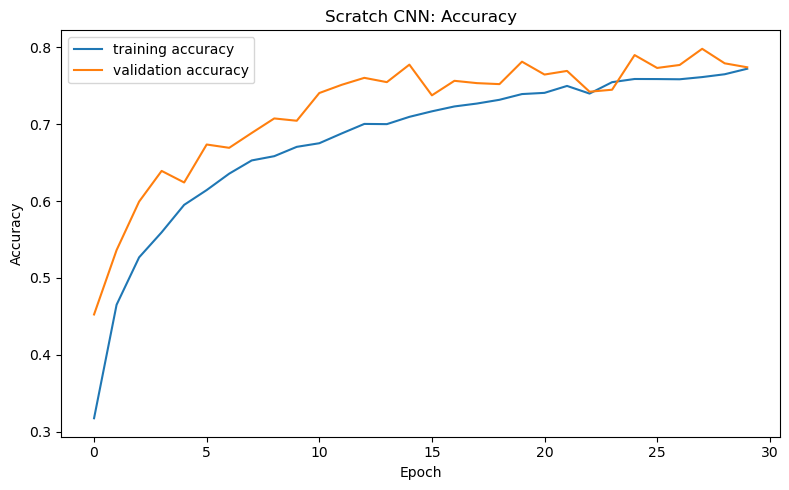

Saved figure to: /home/n11902736/cab420/WasteClassification/scratch_cnn/figures/scratch_CNN_training_history.png/training_loss.png


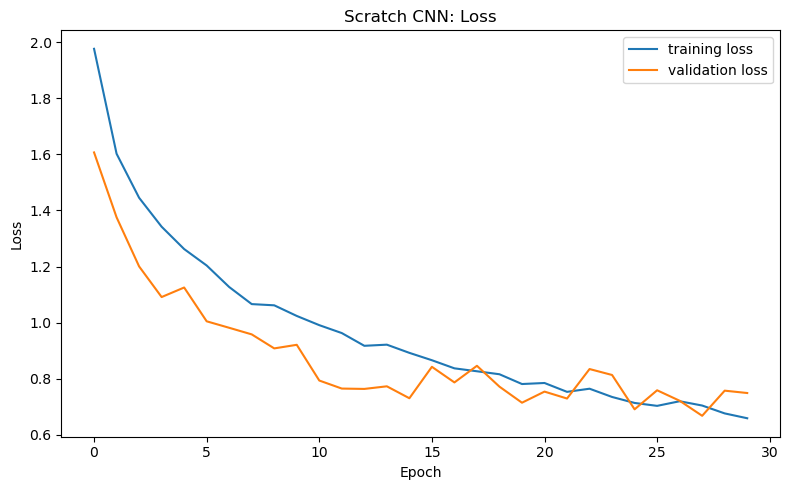

In [14]:
# Show training history plots
plot_training_history(history, title="Scratch CNN", save_dir=FIGURES_DIR/"scratch_CNN_training_history.png",)

340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Scratch CNN
-----------
Training time     : 315.39s
Inference time    : 4.141s
Time per sample   : 1.779ms
-----------
              precision    recall  f1-score   support

     battery     0.6795    0.7465    0.7114       142
  biological     0.6805    0.7770    0.7256       148
 brown-glass     0.9114    0.7912    0.8471        91
   cardboard     0.8120    0.8060    0.8090       134
     clothes     0.9289    0.8836    0.9057       799
 green-glass     0.8087    0.9894    0.8900        94
       metal     0.5714    0.6609    0.6129       115
       paper     0.6599    0.8280    0.7345       157
     plastic     0.6250    0.6538    0.6391       130
       shoes     0.7625    0.6700    0.7133       297
       trash     0.7935    0.6952    0.7411       105
 white-glass     0.6804    0.5690    0.6197       116

    accuracy                         0.7857      2328
   macro avg     0.7428    0.7559    0.74

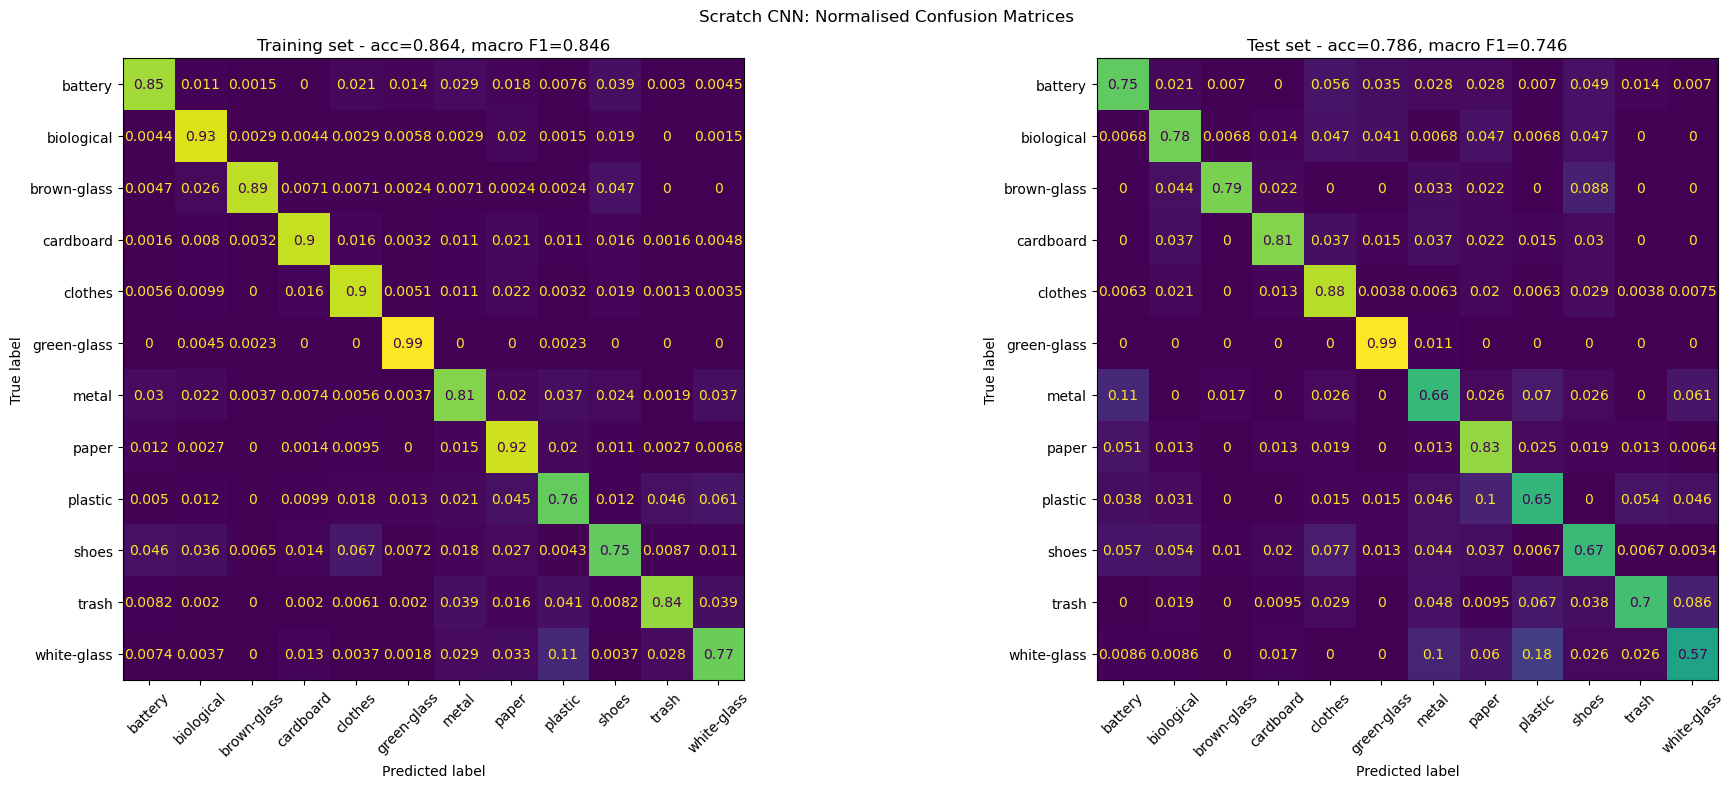

Saved metrics to: /home/n11902736/cab420/WasteClassification/scratch_cnn/scratch_cnn_metrics.json


In [15]:
# Evaluate on training and test sets
start_time = time.perf_counter()

train_prob = model.predict(train_eval_ds)
test_prob = model.predict(test_ds)

inference_time = time.perf_counter() - start_time

train_pred = np.argmax(train_prob, axis=1)
test_pred = np.argmax(test_prob, axis=1)

metrics = eval_model(
    test_labels,
    test_pred,
    class_list,
    model_name="Scratch CNN",
    y_train=train_labels,
    train_pred=train_pred,
    train_time=train_time,
    inference_time=inference_time,
    save_path=FIGURES_DIR/"scratch_cnn_confusion_matrices.png",
)

save_metrics(
    metrics,
    PROJECT_ROOT / "scratch_cnn" / "scratch_cnn_metrics.json",
)

## Save Predictions

In [16]:
predictions_df = pd.DataFrame({
    "path": test_paths,
    "true_label": test_labels,
    "true_class": [class_list[i] for i in test_labels],
    "pred_label": test_pred,
    "pred_class": [class_list[i] for i in test_pred],
    "confidence": np.max(test_prob, axis=1),
    "correct": test_labels == test_pred,
})

predictions_path = PROJECT_ROOT / "scratch_cnn" / "scratch_cnn_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

print("Saved:", predictions_path)
display(predictions_df.head())

Saved: /home/n11902736/cab420/WasteClassification/scratch_cnn/scratch_cnn_predictions.csv


,path,true_label,true_class,pred_label,pred_class,confidence,correct
0,/home/n11902736/cab420/WasteClassification/dat...,0,battery,0,battery,0.985449,True
1,/home/n11902736/cab420/WasteClassification/dat...,0,battery,9,shoes,0.641320,False
2,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,9,shoes,0.789918,True
3,/home/n11902736/cab420/WasteClassification/dat...,4,clothes,4,clothes,0.999817,True
4,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,9,shoes,0.608445,True


## Analysis: High confidence misclassification

In [17]:
wrong_df = predictions_df[predictions_df["correct"] == False].copy()
wrong_df = wrong_df.sort_values("confidence", ascending=False)

display(wrong_df.head(12))

,path,true_label,true_class,pred_label,pred_class,confidence,correct
72,/home/n11902736/cab420/WasteClassification/dat...,8,plastic,10,trash,0.999963,False
2227,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,4,clothes,0.999893,False
2208,/home/n11902736/cab420/WasteClassification/dat...,3,cardboard,4,clothes,0.999824,False
1218,/home/n11902736/cab420/WasteClassification/dat...,0,battery,1,biological,0.999684,False
282,/home/n11902736/cab420/WasteClassification/dat...,8,plastic,10,trash,0.998904,False
1858,/home/n11902736/cab420/WasteClassification/dat...,0,battery,4,clothes,0.997631,False
1587,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,1,biological,0.996901,False
2096,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,1,biological,0.996120,False
1491,/home/n11902736/cab420/WasteClassification/dat...,0,battery,4,clothes,0.994935,False
1252,/home/n11902736/cab420/WasteClassification/dat...,10,trash,8,plastic,0.994438,False


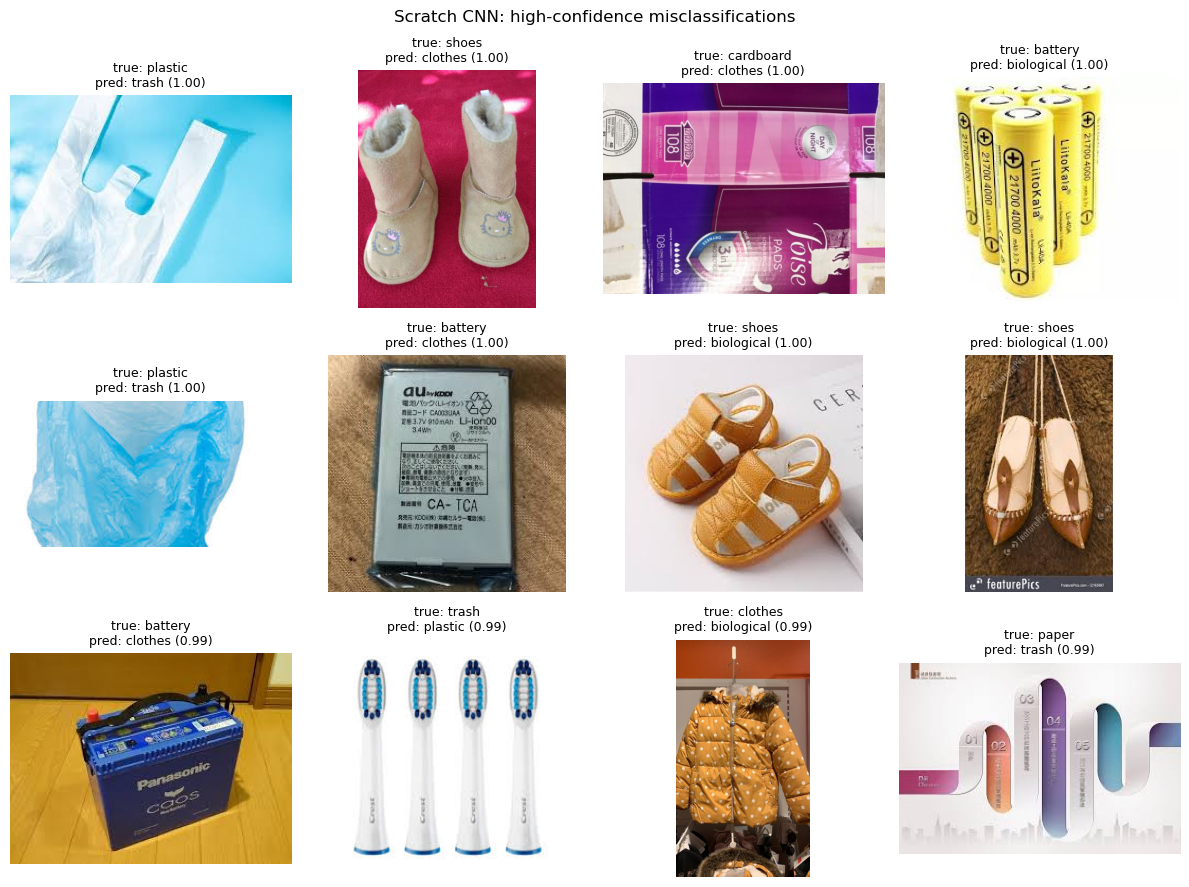

Saved: /home/n11902736/cab420/WasteClassification/scratch_cnn/figures/scratch_cnn_high_confidence_errors.png


In [18]:
# Plot examples
top_k = 12
failure_df = wrong_df.head(top_k)

n_cols = 4
n_rows = int(np.ceil(len(failure_df) / n_cols))

fig = plt.figure(figsize=(12, 3 * n_rows))

for plot_i, (_, row) in enumerate(failure_df.iterrows()):
    ax = fig.add_subplot(n_rows, n_cols, plot_i + 1)

    img = plt.imread(row["path"])
    ax.imshow(img)

    ax.set_title(
        f"true: {row['true_class']}\n"
        f"pred: {row['pred_class']} ({row['confidence']:.2f})",
        fontsize=9,
    )

    ax.axis("off")

fig.suptitle("Scratch CNN: high-confidence misclassifications", fontsize=12)
plt.tight_layout()

figure_path = FIGURES_DIR / "scratch_cnn_high_confidence_errors.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)